In [2]:
import os
import sys
from os.path import join

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("./additional_code")
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxd/Repositories/ESP/our_codes


In [3]:
import warnings

warnings.filterwarnings("ignore")

In [4]:
anotherdata = pd.read_csv(
    our_data + "geneID_ligandID_docking_gnina_Score_std_uni_true.txt",
    sep="\t",
    header=0,
)

In [5]:
result = anotherdata["complex_name"].str.split(r"_", expand=True)
result.columns = ["enzyme", "substrate", "cc"]
result["substrate_cc"] = result["substrate"] + "_" + result["cc"]

anotherdata = pd.concat([anotherdata, result], axis=1)

ourdata = pd.read_pickle(join(CURRENT_DIR, "..", "data", "our_data", "5foldsdata.pkl"))

In [ ]:
print(anotherdata["enzyme"].nunique())
print(anotherdata["substrate"].nunique())
print(ourdata["enzyme"].nunique())
print(ourdata["substrate"].nunique())

299
194
517
237


In [7]:
gninadata = pd.read_pickle(
    join(CURRENT_DIR, "..", "data", "our_data/cache", "gnina.pkl")
)
set(anotherdata["enzyme"].unique().tolist()) - set(gninadata.tolist())

{'5YHJ', 'CYP716S1', 'CYP72A69', 'CYP74C13', 'CYP85A3', 'CYP90C1'}

In [ ]:
result = anotherdata.merge(
    ourdata[["enzyme", "substrate", "scores", "Binding"]],
    on=["enzyme", "substrate"],
    how="left",
)
result = result.dropna()
result.to_pickle(our_data + "combdata.pkl")

In [9]:
print(result["enzyme"].nunique())
print(result["substrate"].nunique())
print(result["complex_name"].nunique())
print(result["substrate_cc"].nunique())

233
146
35214
179


In [ ]:
p450_enzymes = anotherdata["p450_name"].unique()
substrates = anotherdata["substrate_cc"].unique()


cartesian_product = pd.MultiIndex.from_product(
    [p450_enzymes, substrates], names=["p450_name", "substrate_cc"]
).to_frame(index=False)
merged_df = pd.merge(
    cartesian_product, anotherdata, how="left", on=["p450_name", "substrate_cc"]
)
anotherdata = (
    pd.concat([anotherdata, merged_df[merged_df.isnull().any(axis=1)]])
    .drop_duplicates()
    .reset_index(drop=True)
)

In [ ]:
result = anotherdata["substrate_cc"].str.split(r"_", expand=True)
result.columns = ["substrate", "cc"]
anotherdata = anotherdata.drop(columns=["cc"])
anotherdata = anotherdata.drop(columns=["substrate"])
anotherdata = anotherdata.drop(columns=["enzyme"])
anotherdata = anotherdata.drop(columns=["complex_name"])
anotherdata = pd.concat([anotherdata, result], axis=1)

anotherdata["if_right"] = anotherdata["if_right"].fillna(False)
anotherdata["wei_score"] = anotherdata["wei_score"].fillna(0)

In [12]:
anotherdata

,p450_name,p450_score,affinity,cnn_score,cnn_affi,wei_score,dock_num,if_right,substrate_cc,substrate,cc
0,3UA1,0.159,0.014,0.814,0.645,0.486,3.0,True,08Y_C22,08Y,C22
1,CYP707A1,0.097,0.043,0.628,0.553,0.362,4.0,False,08Y_C22,08Y,C22
2,CYP76B10,0.187,0.100,0.601,0.640,0.394,4.0,False,08Y_C22,08Y,C22
3,CYP72A208,0.172,0.072,0.597,0.550,0.384,4.0,False,08Y_C22,08Y,C22
4,CYP725A4,0.093,0.011,0.592,0.563,0.342,4.0,False,08Y_C22,08Y,C22
...,...,...,...,...,...,...,...,...,...,...,...
68466,CYP72A69,NaN,NaN,NaN,NaN,0.000,NaN,False,BAM_C29,BAM,C29
68467,CYP72A69,NaN,NaN,NaN,NaN,0.000,NaN,False,ADI_C14,ADI,C14
68468,CYP72A69,NaN,NaN,NaN,NaN,0.000,NaN,False,AGI_C9,AGI,C9
68469,CYP72A69,NaN,NaN,NaN,NaN,0.000,NaN,False,ACA_C34,ACA,C34


In [13]:
result = anotherdata[
    ["p450_name", "substrate", "cc", "substrate_cc", "wei_score", "if_right"]
].merge(
    ourdata[["enzyme", "substrate", "scores", "Binding"]],
    left_on=["p450_name", "substrate"],
    right_on=["enzyme", "substrate"],
    how="left",
)
result = result.dropna()

result["wei_score"] = result["wei_score"].round(3)
result["scores"] = result["scores"].round(3)

In [14]:
result

,p450_name,substrate,cc,substrate_cc,wei_score,if_right,enzyme,scores,Binding
2566,CYP72A66v2,ABA,C14,ABA_C14,0.529,False,CYP72A66v2,0.236,0.0
2567,CYP72A7,ABA,C14,ABA_C14,0.513,False,CYP72A7,0.121,0.0
2568,CYP72A62v2,ABA,C14,ABA_C14,0.485,False,CYP72A62v2,0.024,0.0
2570,CYP707A1,ABA,C14,ABA_C14,0.422,False,CYP707A1,0.027,0.0
2571,CYP72A475,ABA,C14,ABA_C14,0.453,False,CYP72A475,0.116,0.0
...,...,...,...,...,...,...,...,...,...
68466,CYP72A69,BAM,C29,BAM_C29,0.000,False,CYP72A69,0.934,0.0
68467,CYP72A69,ADI,C14,ADI_C14,0.000,False,CYP72A69,0.009,0.0
68468,CYP72A69,AGI,C9,AGI_C9,0.000,False,CYP72A69,0.007,0.0
68469,CYP72A69,ACA,C34,ACA_C34,0.000,False,CYP72A69,0.060,0.0


In [15]:
print(result["enzyme"].nunique())
print(result["substrate"].nunique())

233
146


In [15]:
binding_1_values = result[(result["if_right"] == True) & (result["Binding"] == 1)]

In [ ]:
enzymess = binding_1_values["p450_name"].unique()
substrateccss = binding_1_values["substrate_cc"].unique()
substratess = binding_1_values["substrate"].unique()
cartesian_product_esp = pd.MultiIndex.from_product(
    [enzymess, substratess], names=["P450 enzyme", "substrate"]
).to_frame(index=False)

cartesian_product_gnina = pd.MultiIndex.from_product(
    [enzymess, substrateccss], names=["P450 enzyme", "substrate_cc"]
).to_frame(index=False)

In [17]:
dfs13 = ourdata[["enzyme", "substrate", "Binding", "scores"]]
dfs14 = anotherdata[
    ["p450_name", "substrate", "cc", "substrate_cc", "wei_score", "if_right"]
]

dfs13.rename(columns={"enzyme": "P450 enzyme"}, inplace=True)
dfs13.rename(columns={"Binding": "whether catalyzed"}, inplace=True)
dfs13.rename(columns={"scores": "Prediction Scores"}, inplace=True)

dfs14.rename(columns={"p450_name": "P450 enzyme"}, inplace=True)
dfs14.rename(columns={"cc": "Reaction_Sites"}, inplace=True)
dfs14.rename(columns={"if_right": "whether catalyzed"}, inplace=True)
dfs14.rename(columns={"wei_score": "Prediction Scores"}, inplace=True)
dfs14["whether catalyzed"] = dfs14["whether catalyzed"].astype(int)

In [18]:
merged_df = pd.merge(
    cartesian_product_esp, dfs13, how="left", on=["P450 enzyme", "substrate"]
)
dfs13 = merged_df
dfs13 = dfs13.dropna()

In [19]:
merged_df = pd.merge(
    cartesian_product_gnina, dfs14, how="left", on=["P450 enzyme", "substrate_cc"]
)
dfs14 = merged_df

In [20]:
merged_df = pd.merge(
    cartesian_product_gnina,
    result,
    how="left",
    left_on=["P450 enzyme", "substrate_cc"],
    right_on=["p450_name", "substrate_cc"],
)
result = merged_df

In [21]:
result

,P450 enzyme,substrate_cc,p450_name,substrate,cc,wei_score,if_right,enzyme,scores,Binding
0,CYP706A3,ABA_C14,CYP706A3,ABA,C14,0.405,True,CYP706A3,0.161,1.0
1,CYP706A3,ABI_C17,CYP706A3,ABI,C17,0.314,False,CYP706A3,0.237,0.0
2,CYP706A3,ABS_C5,CYP706A3,ABS,C5,0.236,False,CYP706A3,0.108,0.0
3,CYP706A3,ABT_C12,CYP706A3,ABT,C12,0.257,False,CYP706A3,0.599,0.0
4,CYP706A3,BAM_C15,CYP706A3,BAM,C15,0.000,False,CYP706A3,0.587,0.0
...,...,...,...,...,...,...,...,...,...,...
40770,CYP79A125,BAM_C29,CYP79A125,BAM,C29,0.000,False,CYP79A125,0.050,0.0
40771,CYP79A125,ADI_C14,CYP79A125,ADI,C14,0.329,False,CYP79A125,0.001,0.0
40772,CYP79A125,AGI_C9,CYP79A125,AGI,C9,0.515,False,CYP79A125,0.009,0.0
40773,CYP79A125,ACA_C34,CYP79A125,ACA,C34,0.000,False,CYP79A125,0.005,0.0


In [22]:
for i in range(0, 101):
    result["scores" + str(i)] = (
        result["wei_score"] * i / 100 + result["scores"] * (100 - i) / 100
    )
    result["rank" + str(i)] = result.groupby("substrate_cc")["scores" + str(i)].rank(
        method="first", ascending=False
    )

In [ ]:
ratios_list = []

binding_1_values = result[(result["if_right"] == True) & (result["Binding"] == 1)]
for i in range(0, 101):
    binding_1_values["ranking" + str(i)] = binding_1_values["rank" + str(i)] / 233
    ratios_list.append([i, binding_1_values["ranking" + str(i)].median()])
ratios_df = pd.DataFrame(ratios_list, columns=["i", "median"])

In [24]:
ratios_df

,i,median
0,0,0.068670
1,1,0.068670
2,2,0.064378
3,3,0.064378
4,4,0.064378
...,...,...
96,96,0.042918
97,97,0.051502
98,98,0.060086
99,99,0.068670


In [25]:
ratios_df.sort_values(by="median", ascending=True)

,i,median
77,77,0.025751
78,78,0.025751
83,83,0.025751
82,82,0.025751
79,79,0.025751
...,...,...
2,2,0.064378
0,0,0.068670
1,1,0.068670
99,99,0.068670


In [ ]:
rows = [i for i in range(0, 101, 5)]

ratios_df10 = ratios_df.loc[rows]
ratios_df10["i"] = ratios_df10["i"] * 0.01

In [27]:
ratios_df10

,i,median
0,0.00,0.068670
5,0.05,0.064378
10,0.10,0.060086
15,0.15,0.060086
20,0.20,0.055794
25,0.25,0.047210
30,0.30,0.042918
35,0.35,0.038627
40,0.40,0.038627
45,0.45,0.038627


<Figure size 1000x600 with 0 Axes>

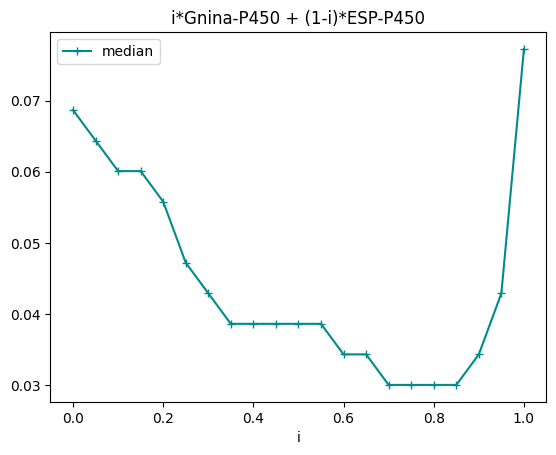

In [ ]:
plt.figure(figsize=(10, 6))
ratios_df10.plot(
    x="i",
    y="median",
    kind="line",
    title="i*Gnina-P450 + (1-i)*ESP-P450",
    marker="+",
    color="#008B8B",
)

plt.show()

In [29]:
dfs13 = dfs13.sort_values(
    by=["substrate", "Prediction Scores"], ascending=[True, False]
)
dfs13["ranking"] = dfs13.groupby("substrate").cumcount() + 1

In [30]:
dfs14 = dfs14.sort_values(
    by=["substrate_cc", "Prediction Scores"], ascending=[True, False]
)
dfs14["ranking"] = dfs14.groupby("substrate_cc").cumcount() + 1

In [31]:
dfs13.to_csv(our_data + "bin/ourESPdata68.csv")
dfs14.to_csv(our_data + "bin/ourGninadata68.csv")

In [ ]:
dfs15 = binding_1_values[["p450_name", "substrate", "cc", "rank70"]]
dfs15.rename(columns={"p450_name": "enzyme"}, inplace=True)
dfs15.rename(columns={"cc": "Reaction_Sites"}, inplace=True)

result_1 = pd.merge(
    dfs13, dfs14, on=["P450 enzyme", "substrate", "whether catalyzed"], how="inner"
)
result_1.rename(columns={"ranking_y": "rank_Gnina-P450"}, inplace=True)
result_1.rename(columns={"ranking_x": "rank_ESP-P450"}, inplace=True)

result_2 = pd.merge(
    result_1,
    dfs15,
    left_on=["P450 enzyme", "substrate"],
    right_on=["enzyme", "substrate"],
    how="inner",
)
dfs15 = result_2[
    [
        "enzyme",
        "substrate",
        "Reaction_Sites_y",
        "rank70",
        "rank_ESP-P450",
        "rank_Gnina-P450",
    ]
]
dfs15.rename(columns={"Reaction_Sites_y": "Reaction_Sites"}, inplace=True)

In [33]:
dfs15.to_csv(our_data + "bin/ourcomb68.csv")

In [34]:
merged_df.to_csv(our_data + "bin/sheetall.csv")

In [36]:
sheet_df = merged_df[
    ["P450 enzyme", "substrate", "Binding", "if_right", "scores", "wei_score", "cc"]
]
sheet_df.rename(
    columns={
        "P450 enzyme": "enzyme",
        "wei_score": "Gnina_score",
        "scores": "ESP_p450_score",
    },
    inplace=True,
)
sheet_df.to_csv("../compare/input/sheetall.csv", index=False)

In [37]:
print(merged_df["P450 enzyme"].nunique())
print(merged_df["substrate"].nunique())
print(merged_df["substrate_cc"].nunique())

233
144
175
